### Part A

Program Polak-Ribiere and Fletcher-Reeves conjugate gradient methods with exact line search to minimize the Rosenbrock 
function:

In [1]:
import numpy as np
from numpy.linalg import norm, solve, multi_dot
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

In [2]:
f = lambda x,y: 100*(y-x**2)**2+(1-x)**2
Df = lambda x,y: np.array([400*x**3-400*x*y-2+2*x,
                           200*y - 200*x**2])

In [3]:
def PR_beta(Dfk,Dfk1, pk):
    return ((Dfk1-Dfk)@Dfk1) / (Dfk@Dfk)

In [4]:
def FR_beta(Dfk,Dfk1, pk): 
    return (Dfk1@Dfk1) / (Dfk@Dfk)

In [66]:
%%time
def nonlinearCG(x0, y0, f, Df, beta, restart=True, tol=1e-8, max_steps=10000):
    x,y = x0,y0
    path = [[x,y]]
    i=0                   
    dx = Df(x,y)          
    pk = -dx
    while norm(dx) > tol and i<max_steps:
        def subproblem1D(alpha): #exact line search
            return f(x + alpha * pk[0],y+alpha*pk[1])
        res = minimize_scalar(subproblem1D)
        alpha = res.x      
        xnew,ynew = x + alpha*pk[0], y + alpha*pk[1]
        dx1 = Df(xnew,ynew)      # Df_{k+1}
        bk = beta(dx,dx1,pk)  # beta_k
        if restart and i%3 == 0: #restarting after 3 iterations
            bk=0
        pk = -dx1 + bk*pk
        path.append([xnew,ynew])
        x,y = xnew,ynew
        dx = dx1
        i += 1
    return np.array(path), i, x, y

CPU times: user 23 µs, sys: 47 µs, total: 70 µs
Wall time: 77 µs


#### Polak-Ribiere conjugate gradient method with exact line search 

In [67]:
x0 = 1.2; y0=1.2
path_PR, i, x, y = nonlinearCG(x0, y0, f, Df, PR_beta, False)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 10 iterations, approximate minimum is 2.154344126455914e-25 at (1.0000000000004168, 1.000000000000854)


In [68]:
def plot_path(path, func, title, window=[0,3,0,3], numContours=50, skip=1):
    '''Plots path defined in (N,2) array "path" on a contour plot of "func" in window "window"'''
    plt.figure(figsize=(10,10))
    X = np.linspace(window[0],window[1],300)
    Y = np.linspace(window[2],window[3],300)
    Xmesh, Ymesh = np.meshgrid(X,Y)
    Z = func(Xmesh,Ymesh)
    CS = plt.contour(Xmesh, Ymesh, Z, numContours, cmap='jet')
    plt.clabel(CS,inline_spacing=0,fmt='%d')
    plt.axis(window)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)

    for i in range(path.shape[0]-1): # iterate through steps
        if i%skip==0:
            # only plot arrows every "skip" iterations
            plt.arrow(path[i,0],path[i,1],path[i+1,0]-path[i,0],path[i+1,1]-path[i,1],
                      color='k',length_includes_head=True)
    plt.show()

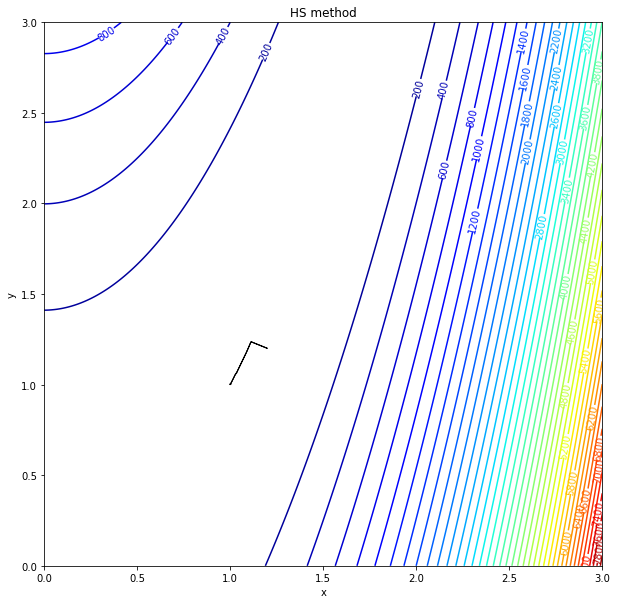

In [69]:
plot_path(path_PR,f,'HS method')

[0.9252745101287755, 0.7813834797569937, 0.3398325236304714, 0.9558149858445973, 0.14435000468432402, 0.3410571397923744, 0.02382987543798532, 0.015931556769152536, 0.000233624620963406, 0.0032762777406467576]


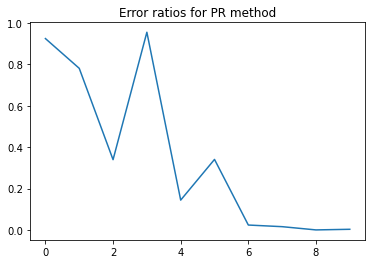

In [70]:
err1 = path_PR - np.array([1,1])
ratios1 = [np.linalg.norm(err1[k+1])/ np.linalg.norm(err1[k]) for k in range(len(err1)-1)]
plt.plot(ratios1)
plt.title("Error ratios for PR method")
print(ratios1)

The convergence rate is linear

#### Fletcher-Reeves conjugate gradient method with exact line search

In [71]:
path_FR, i, x, y=nonlinearCG(x0, y0, f, Df, FR_beta, False)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 30 iterations, approximate minimum is 3.7122174014934155e-17 at (1.0000000060836387, 1.0000000122006711)


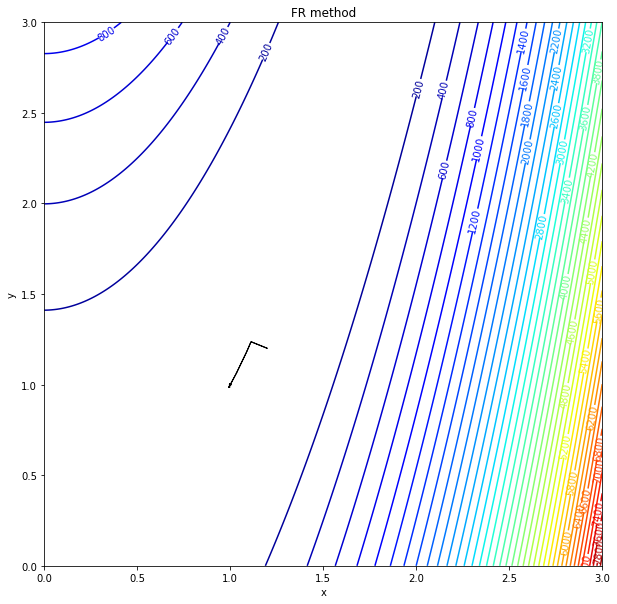

In [72]:
plot_path(path_FR,f,'FR method')

[0.9252745101287755, 0.7814496804402103, 0.3398481291756144, 0.17440102339816588, 1.0892926461945283, 0.9998960969953012, 0.9911062654154194, 0.1814877003862766, 0.3534142012023115, 1.0191535629223143, 0.9996805178937488, 0.9783128859018942, 0.11740324682474952, 0.5425778910548544, 1.0133089376298767, 0.9996166357387724, 0.9687300241988307, 0.06360091873594646, 1.0175049079965417, 1.0086264384132915, 0.9995323101404833, 0.9534401975873388, 0.02428619197805279, 2.71545582400228, 1.0055775294083986, 0.9994208822542435, 0.9312411284146694, 0.007570143841649601, 8.939270701069061, 1.003565690449995]


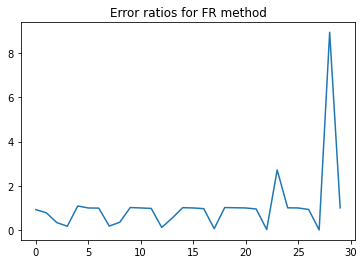

In [73]:
err2 = path_FR - np.array([1,1])
ratios2 = [np.linalg.norm(err2[k+1])/ np.linalg.norm(err2[k]) for k in range(len(err2)-1)]
plt.plot(ratios2)
plt.title("Error ratios for FR method")
print(ratios2)

The convergence rate is linear since most of the limits are closed to 1. 

Even though they have the same convergence rate, PR converges faster than FR with less iterations

### Part B

Repeat A by performing direction vector restart every 3 iterations. 

#### Polak-Ribiere conjugate gradient methods with restarting every 3 iterations

In [74]:
x0 = 1.2; y0=1.2
path_PR1, i, x, y = nonlinearCG(x0, y0, f, Df, PR_beta, True)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 13 iterations, approximate minimum is 6.669173073777505e-26 at (1.0000000000002582, 1.0000000000005167)


[0.9252745101287755, 0.7874610919097573, 0.3440302925418238, 0.9469842592936921, 0.9995142067365405, 0.11222330041154954, 0.4643499159765441, 0.9995894062748998, 0.0005363096452032954, 0.43797514515068126, 0.9987514553236981, 0.00011465978881788327, 0.006143240140291785]


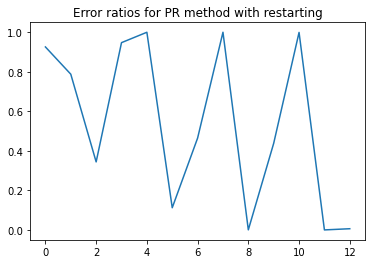

In [75]:
err3 = path_PR1 - np.array([1,1])
ratios3 = [np.linalg.norm(err3[k+1])/ np.linalg.norm(err3[k]) for k in range(len(err3)-1)]
plt.plot(ratios3)
plt.title("Error ratios for PR method with restarting")
print(ratios3)

The convergence rate is still linear since most of the limits are closed to 1

#### Fletcher-Reeves conjugate gradient methods with restarting every 3 iterations

In [76]:
path_FR1, i, x, y=nonlinearCG(x0, y0, f, Df, FR_beta, True)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 10 iterations, approximate minimum is 2.728533225975098e-20 at (1.0000000001650586, 1.0000000003307574)


[0.9252745101287755, 0.7874610919097573, 0.3440303429981909, 0.17250534730539205, 0.9991508275567844, 0.005015475778051516, 0.5243076332654428, 0.9995313190433801, 2.9528046917775382e-05, 0.3897553518533094]


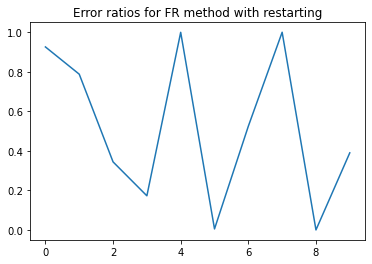

In [77]:
err4 = path_FR1 - np.array([1,1])
ratios4 = [np.linalg.norm(err4[k+1])/ np.linalg.norm(err4[k]) for k in range(len(err4)-1)]
plt.plot(ratios4)
plt.title("Error ratios for FR method with restarting")
print(ratios4)

The convergence rate is linear. 

Even though they have the same convergence rate, FR converges faster compare to PR in this case with restarting every 3 steps.

### Part C

Repeat A & B for initial point (-1.2, 1).

#### Polak-Ribiere conjugate gradient method 

In [78]:
x0 = -1.2; y0=1
path_PR2, i, x, y = nonlinearCG(x0, y0, f, Df, PR_beta, False)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 18 iterations, approximate minimum is 4.64926058653541e-20 at (0.9999999999539316, 0.9999999999289275)


[0.9233139332347562, 0.9536543479171289, 0.9493913021587747, 0.8801935953191723, 0.9939048653319743, 0.9535131169594324, 0.9264458428631713, 0.9618530312279782, 0.9247793897219017, 0.9252712224432951, 0.37359120781962646, 1.0042522898756123, 0.6274562118090797, 0.021506898827720843, 1.234498002925838, 0.002049512298314811, 0.1864952554753801, 3.0308538283269285e-05]


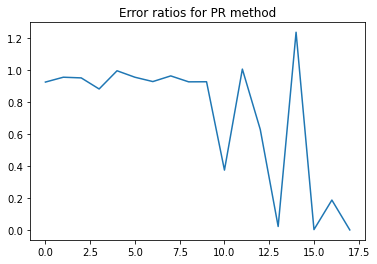

In [79]:
err5 = path_PR2 - np.array([1,1])
ratios5 = [np.linalg.norm(err5[k+1])/ np.linalg.norm(err5[k]) for k in range(len(err5)-1)]
plt.plot(ratios5)
plt.title("Error ratios for PR method")
print(ratios5)

The convergence rate is linear 

#### Polak-Ribiere conjugate gradient method with restarting 

In [80]:
path_PR3, i, x, y = nonlinearCG(x0, y0, f, Df, PR_beta, True)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 27 iterations, approximate minimum is 1.8696170715545935e-21 at (0.9999999999954389, 0.9999999999951775)


[0.9233139332347562, 0.9585160095156752, 0.9471059611616458, 0.8858958958829071, 0.9775141791050364, 0.9607476650848166, 0.9660966183678156, 0.9706564640089558, 0.9340994739349245, 0.9305102757819226, 0.9842467272584502, 0.8799104239591816, 0.8374121388497534, 0.9943997929888925, 0.7948024005552008, 0.6576704797282393, 0.998095080332481, 0.6320494116688206, 0.16978934992625258, 0.9991204655014794, 0.07229616027751862, 0.5220171132674979, 0.9995894259358067, 0.0002143884441711349, 0.3397393593160714, 0.9958142800836659, 4.808713260565885e-05]


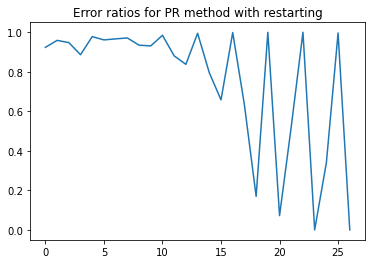

In [81]:
err6 = path_PR3 - np.array([1,1])
ratios6 = [np.linalg.norm(err6[k+1])/ np.linalg.norm(err6[k]) for k in range(len(err6)-1)]
plt.plot(ratios6)
plt.title("Error ratios for PR method with restarting")
print(ratios6)

The convergence rate is linear

#### Fletcher-Reeves conjugate gradient method

In [82]:
path_FR2, i, x, y=nonlinearCG(x0, y0, f, Df, FR_beta, False)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 217 iterations, approximate minimum is 1.7063332243308967e-17 at (1.000000004130744, 1.0000000082597953)


[0.9233139332347562, 0.9536544367875801, 0.9493467821452091, 0.9717115548504202, 0.9808137969283182, 0.9852370161543648, 0.9875454629103065, 0.9887690761841406, 0.9893881780840769, 0.9896474830008585, 0.9896785497203504, 0.989554104204642, 0.9893143342710061, 0.9889804924564388, 0.9885622409542549, 0.9880617111851544, 0.9874758011481821, 0.9867973961040815, 0.9860159726171239, 0.9851177347521629, 0.9840854421304999, 0.9828979346467611, 0.9815293744589696, 0.9799480850133097, 0.9781150220771063, 0.9759815415488479, 0.9734863441857111, 0.9705511220165727, 0.9670742812496222, 0.9629216873648595, 0.9579126673457418, 0.9517982027756883, 0.9442257663205789, 0.9346802776820589, 0.9223800597552613, 0.9060824370094698, 0.8836933202421451, 0.8514066066278331, 0.8015640184249715, 0.7163675108645503, 0.544953376574142, 0.27305138279701907, 4.74096896347201, 2.1723958057297965, 1.7210480972356956, 1.4758677442346522, 1.0338749437887271, 1.0007545550412293, 0.9999104744616975, 0.9983766813904073, 0.

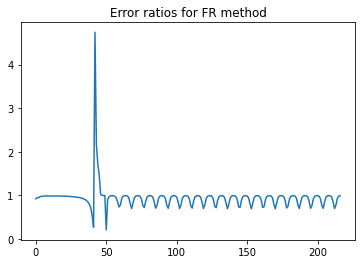

In [83]:
err7 = path_FR2 - np.array([1,1])
ratios7 = [np.linalg.norm(err7[k+1])/ np.linalg.norm(err7[k]) for k in range(len(err7)-1)]
plt.plot(ratios7)
plt.title("Error ratios for FR method")
print(ratios7)

The convergence rate is linear

#### Fletcher-Reeves conjugate gradient method with restarting

In [84]:
path_FR3, i, x, y=nonlinearCG(x0, y0, f, Df, FR_beta, True)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 19 iterations, approximate minimum is 3.359242154539136e-17 at (1.0000000057885516, 1.0000000116062737)


[0.9233139332347562, 0.9585160095156752, 0.9471059611890332, 0.9708670668031092, 0.9735895633776491, 0.9647016291422091, 0.9757714929998599, 0.5515692717679098, 0.9998511289726455, 0.9069888579932425, 0.9996292332516922, 0.6459481153165757, 0.564181893760022, 0.9991784809146024, 0.46855130832035186, 0.0049356595890117, 0.7681930369224566, 0.00024495273324403314, 0.09976809492517373]


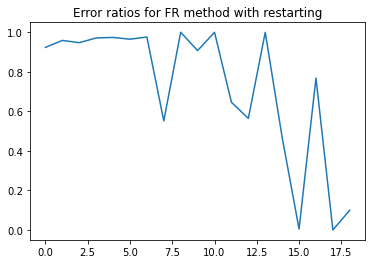

In [85]:
err8 = path_FR3 - np.array([1,1])
ratios8 = [np.linalg.norm(err8[k+1])/ np.linalg.norm(err8[k]) for k in range(len(err8)-1)]
plt.plot(ratios8)
plt.title("Error ratios for FR method with restarting")
print(ratios8)

The convergence rate is linear

Even though both of them converge linearly, it took both of them much more iterations when choose a different staring point. For FR, it requires more iterations when using restarting, but PR save a lot of steps when using restarting. 